# 03 Models Baseline

Этот ноутбук обучает **модели на каждом fold** и считает метрики качества:

**Линейные/байесовские:**
1. **Ridge** — L2 регуляризация (аналог RR-BLUP/GBLUP)
2. **Lasso** — L1 регуляризация (отбор признаков)
3. **Elastic Net** — комбинация L1 + L2
4. **Bayes_A** — байесовская регрессия с t-приором
5. **Bayes_B** — spike-and-slab prior
6. **Bayes_C** — normal spike-and-slab
7. **gBLUP** — genomic BLUP через mixed linear model (GRM + BLUPs)

**Машинное обучение:**

8. **SVR** — Support Vector Regression (RBF kernel), Qiu et al. 2022: +19% над GBLUP
9. **RandomForest** — ансамбль деревьев, Qiu et al. 2022: +8.9% над GBLUP
10. **XGBoost** — градиентный бустинг (optional: `uv sync --extra ml`)
11. **LightGBM** — быстрый градиентный бустинг (optional: `uv sync --extra ml`)

Для каждой модели считаем: `corr` (корреляция), `rmse`, `mae`, `r2`.

**Для кого**: для тех, кто хочет увидеть, как разные модели работают на одних данных и какие показывают лучшие результаты.

In [ ]:
import sys
sys.path.insert(0, '..')

from pathlib import Path

from gp_py.io import fn_load_genotype, fn_load_phenotype
from gp_py.cv import fn_cross_validation_within_population
from gp_py.schema import MergedData

## 1. Подготовка данных

In [2]:
DATA_DIR = Path("../inst/exec_Rscript/input")

G = fn_load_genotype(str(DATA_DIR / "test_geno.Rds"))
list_pheno = fn_load_phenotype(str(DATA_DIR / "test_pheno.tsv"))

# Фильтруем genotype
from gp_py.io import fn_filter_genotype, fn_filter_phenotype, fn_merge_genotype_and_phenotype

Gf = fn_filter_genotype(G)
phf = fn_filter_phenotype(list_pheno)
merged = fn_merge_genotype_and_phenotype(Gf, phf)

# Оставляем только известные фенотипы для CV
known_mask = merged.y.notna()
merged_known = MergedData(
    G=merged.G.loc[known_mask].copy(),
    y=merged.y.loc[known_mask].copy(),
    pop=merged.pop.loc[known_mask].copy(),
    trait_name=merged.trait_name,
)

print(f"Размер данных для CV: {merged_known.G.shape}")
print(f"Популяции: {merged_known.pop.unique()}")

Размер данных для CV: (475, 1000)
Популяции: <ArrowStringArray>
['pop_1', 'pop_2', 'pop_3']
Length: 3, dtype: str


## 2. Запуск CV с несколькими моделями

In [3]:
# Параметры
N_FOLDS = 3
N_REPS = 2

# Модели: линейные/байесовские + ML (SVR, RandomForest всегда доступны)
MODELS = (
    "ridge", "lasso", "elastic_net",
    # "Bayes_A", "Bayes_B", "Bayes_C", 
    "gBLUP",
    "SVR", "RandomForest",
    "XGBoost", "LightGBM",  # требуют: uv sync --extra ml
)

# Альтернатива: только ML для сравнения с GBLUP
# MODELS = ("gBLUP", "SVR", "RandomForest", "XGBoost", "LightGBM")

print("Запускаем кросс-валидацию...")
print(f"Модели: {MODELS}")
cv_results = fn_cross_validation_within_population(
    merged_known,
    n_folds=N_FOLDS,
    n_reps=N_REPS,
    vec_models_to_test=MODELS,
    bool_parallel=False,  # для наглядности, sequential
    bayes_backend="native",  # без R; используйте "rbridge" если R доступен
    verbose=True
)

print("Готово!")

Запускаем кросс-валидацию...
Модели: ('ridge', 'lasso', 'elastic_net', 'gBLUP', 'SVR', 'RandomForest', 'XGBoost', 'LightGBM')


CV folds:   0%|          | 0/48 [00:00<?, ?it/s]

CV folds:   6%|▋         | 3/48 [00:31<09:32, 12.71s/it]/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:715: UserWarning: Using deprecated variance components format
  warnings.warn("Using deprecated variance components format")


Optimization terminated successfully.
         Current function value: 1.670323
         Iterations: 6
         Function evaluations: 8
         Gradient evaluations: 8


CV folds:  15%|█▍        | 7/48 [01:41<13:20, 19.54s/it]/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
CV folds:  19%|█▉        | 9/48 [02:46<14:58, 23.04s/it]/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.571e-02, tolerance: 5.877e-02
  model = cd_fast.enet_coordinate_descent(
CV folds:  23%|██▎       | 11/48 [03:18<12:25, 20.14s/it]/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:715: UserWarning: Using deprecated variance components format
  warnin

...

[gBLUP] GRM was not positive-definite; added diagonal load.
Optimization terminated successfully.
         Current function value: 1.696400
         Iterations: 6
         Function evaluations: 8
         Gradient evaluations: 8


CV folds:  81%|████████▏ | 39/48 [04:47<00:19,  2.14s/it]/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
CV folds:  90%|████████▉ | 43/48 [05:15<00:32,  6.50s/it]/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:715: UserWarning: Using deprecated variance components format
  warnings.warn("Using deprecated variance components format")


[gBLUP] GRM was not positive-definite; added diagonal load.
Optimization terminated successfully.
         Current function value: 1.675622
         Iterations: 6
         Function evaluations: 8
         Gradient evaluations: 8


CV folds:  98%|█████████▊| 47/48 [05:16<00:02,  2.36s/it]/home/vadim/work/projects/genomic-ml-playground/gp/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
CV folds: 100%|██████████| 48/48 [05:16<00:00,  6.60s/it]


Готово!


## 3. Результаты CV — сводная таблица метрик

In [4]:
metrics_df = cv_results["METRICS_WITHIN_POP"]
print("=== Метрики по всем fold-ам ===")
print(metrics_df.head(10).to_string())

=== Метрики по всем fold-ам ===
   rep  fold         model       mbe       mae      rmse        r2      corr  corr_rank  power_t10  power_b10  var_additive  var_residual        h2
0    1     1         ridge -0.003562  1.021516  1.282493  0.257424  0.515174   0.469602     0.4375     0.4375      0.404269      1.655186  0.196299
1    1     1         lasso  0.018125  0.891964  1.126001  0.427588  0.674018   0.655592     0.5000     0.4375      0.582112      1.275573  0.313353
2    1     1   elastic_net  0.022458  0.895866  1.131625  0.421856  0.674605   0.657565     0.4375     0.4375      0.541587      1.288173  0.295988
3    1     1         gBLUP -0.103552  1.135641  1.432216  0.073921  0.374292   0.351430     0.1875     0.3125      0.862208      2.053433  0.295718
4    1     1           SVR  0.037769  1.046579  1.318901  0.214664  0.487436   0.456314     0.3750     0.3125      0.254875      1.749075  0.127186
5    1     1  RandomForest  0.001112  1.045848  1.299116  0.238050  0.546561   0

## 4. Агрегированные метрики по моделям

In [5]:
# Среднее и std по моделям
agg = metrics_df.groupby("model").agg({
    "corr": ["mean", "std"],
    "rmse": ["mean", "std"],
    "mae": ["mean", "std"],
    "r2": ["mean", "std"]
}).round(4)

print("=== Среднее ± std метрик по моделям ===")
print(agg.to_string())

=== Среднее ± std метрик по моделям ===
                corr            rmse             mae              r2        
                mean     std    mean     std    mean     std    mean     std
model                                                                       
LightGBM      0.5586  0.0291  1.2019  0.0324  0.9503  0.0264  0.3053  0.0366
RandomForest  0.5288  0.0347  1.2719  0.0451  1.0035  0.0308  0.2232  0.0189
SVR           0.5058  0.0477  1.2692  0.0486  0.9958  0.0366  0.2263  0.0316
XGBoost       0.5359  0.0345  1.2213  0.0552  0.9664  0.0411  0.2836  0.0346
elastic_net   0.6521  0.0368  1.1070  0.0327  0.8594  0.0328  0.4104  0.0390
gBLUP         0.3362  0.0353  1.5764  0.1323  1.2420  0.1371 -0.2167  0.3162
lasso         0.6514  0.0357  1.1112  0.0283  0.8617  0.0278  0.4062  0.0324
ridge         0.5301  0.0411  1.2404  0.0386  0.9811  0.0413  0.2584  0.0727


## 5. Визуализация: сравнение моделей по корреляции

/tmp/ipykernel_20132/1787638210.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(data_for_box, labels=models, patch_artist=True)


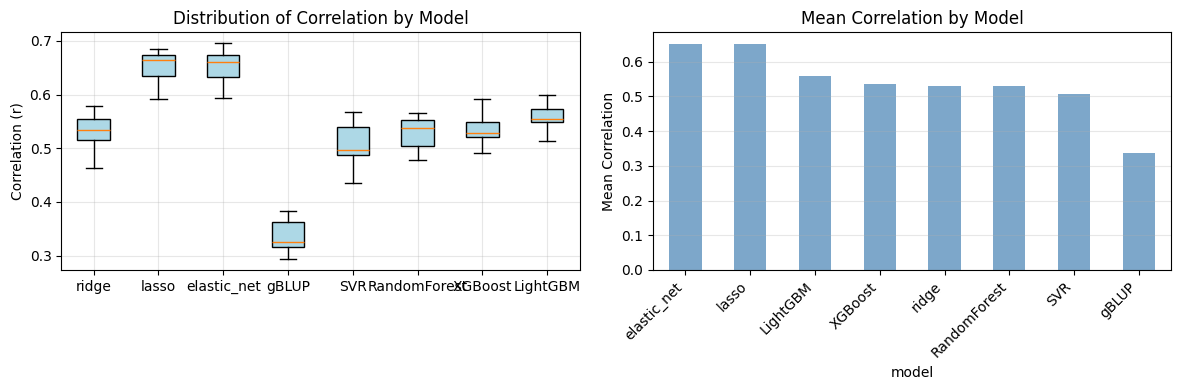

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot корреляций
ax1 = axes[0]
models = metrics_df["model"].unique()
data_for_box = [metrics_df[metrics_df["model"] == m]["corr"].values for m in models]
bp = ax1.boxplot(data_for_box, labels=models, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightblue")
ax1.set_ylabel("Correlation (r)")
ax1.set_title("Distribution of Correlation by Model")
ax1.grid(True, alpha=0.3)

# Barplot средней корреляции
ax2 = axes[1]
mean_corr = metrics_df.groupby("model")["corr"].mean().sort_values(ascending=False)
mean_corr.plot(kind="bar", ax=ax2, color="steelblue", alpha=0.7)
ax2.set_ylabel("Mean Correlation")
ax2.set_title("Mean Correlation by Model")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Лучшая модель

In [7]:
best_model = metrics_df.groupby("model")["corr"].mean().idxmax()
best_corr = metrics_df.groupby("model")["corr"].mean().max()

print("=== Лучшая модель по средней корреляции ===")
print(f"  Модель: {best_model}")
print(f"  Средняя корреляция: {best_corr:.4f}")

=== Лучшая модель по средней корреляции ===
  Модель: elastic_net
  Средняя корреляция: 0.6521


## Итог

- Мы обучили 3 модели (Ridge, Lasso, Elastic Net) на 3 folds × 2 reps = 6 итераций
- Для каждой модели получили метрики: corr, rmse, mae, r2
- Лучшая модель определяется по средней корреляции на validation-фолдах
- Эта лучшая модель будет использоваться для предсказания пропущенных фенотипов

**Следующий шаг**: перейти к ноутбуку `04_missing_phenotype_prediction`, чтобы увидеть, как лучшая модель предсказывает пропущенные значения.